# Google Trends Analysis — Public Search Interest as Priming Proxy

### How to get the data (5 minutes of manual work):

1.  Go to https://trends.google.com/trends/explore
2.  Set **country** to "Norway"
3.  Set **time range** to "Custom" → `2025-01-01` to `2025-09-15`
4.  Compare up to 5 search terms at a time. Do two batches:

**Batch A — FrP-owned vs Labour-owned terms:**

- `Stoltenberg` vs `innvandring` vs `strømpris` vs `NATO`

**Batch B — Deeper issue comparison:**

- `kriminalitet` vs `forsvar` vs `formuesskatt` vs `Listhaug`

. For each batch, click the **download button** (↓ icon) → saves a CSV 6. Put the CSVs in `data/google_trends/` and name them: - `batch_a.csv` (or whatever you like — configure below)

Google Trends CSVs have a header section (3 rows) then `Week, Term1, Term2...`
The code below handles this automatically.


In [16]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

In [22]:
# =============================================================================
# CONFIGURATION
# =============================================================================
TRENDS_DIR = Path("../data/google_trends")
TRENDS_DIR.mkdir(parents=True, exist_ok=True)

TREATMENT_DATE = pd.Timestamp("2025-02-04")
BEFORE_START = pd.Timestamp("2025-01-13")
BEFORE_END = pd.Timestamp("2025-02-03")
AFTER_START = pd.Timestamp("2025-02-04")
AFTER_END = pd.Timestamp("2025-02-21")
ELECT_START = pd.Timestamp("2025-08-18")
ELECT_END = pd.Timestamp("2025-09-08")

BEFORE_START = pd.Timestamp("2025-01-01")  # 5 weeks before
BEFORE_END = pd.Timestamp("2025-02-03")

AFTER_START = pd.Timestamp("2025-02-04")  # 8 weeks after (includes appointment day)
AFTER_END = pd.Timestamp("2025-04-01")

ELECT_START = pd.Timestamp("2025-07-01")  # 10 weeks pre-election (summer + campaign)
ELECT_END = pd.Timestamp("2025-09-08")

# =============================================================================
# SEARCH TERM → ISSUE MAPPING
# Define your terms and which issue they proxy for.
# Adjust these to match exactly what you typed into Google Trends.
# =============================================================================
TERM_CONFIG = {
    # term as it appears in CSV header → (display label, issue group, color, linestyle)
    "Stoltenberg": ("Stoltenberg", "Labour-owned", "#2E6B9E", "-"),
    "NATO": ("NATO", "Labour-owned", "#1B3A5C", "--"),
    "forsvar": ("forsvar (defence)", "Labour-owned", "#6BAED6", "-."),
    "innvandring": ("innvandring (immigration)", "FrP-owned", "#C0392B", "-"),
    "strømpris": ("strømpris (electricity price)", "FrP-owned", "#E67E22", "--"),
    "kriminalitet": ("kriminalitet (crime)", "FrP-owned", "#E74C3C", "-."),
    "formuesskatt": ("formuesskatt (wealth tax)", "Contested", "#27AE60", "-"),
    "Listhaug": ("Listhaug", "FrP-leader", "#E6142D", ":"),
    "Solberg": ("Solberg", "H-leader", "#333333", ":"),
}

# Toggle which terms to plot
SHOW_TERMS = {
    "Stoltenberg": True,
    "NATO": True,
    "forsvar": True,
    "innvandring": True,
    "strømpris": True,
    "kriminalitet": True,
    "formuesskatt": True,
    "Listhaug": True,
    "Solberg": True,
}

WINDOW_GT = 1  # rolling window (1 = no smoothing; Google Trends is already weekly)

# Sciences Po style (reuse from main notebook if already defined)
SCPO_RED = "#E6142D"
SCPO_DARKGREY = "#333333"
SCPO_MIDGREY = "#6B6B6B"
SCPO_LIGHTGREY = "#E8E8E8"
SCPO_OFFWHITE = "#F7F7F7"
PAL = {"blue_dark": "#1B3A5C", "teal": "#3A9E8F", "blue": "#2E6B9E"}

PERIOD_COLORS = {"BEFORE": PAL["blue_dark"], "AFTER": SCPO_RED, "ELECTION": PAL["teal"]}
PERIOD_LABELS = {
    "BEFORE": "Before\n(Jan 2025)",
    "AFTER": "After Stoltenberg\n(Feb 2025)",
    "ELECTION": "Pre-election\n(Aug–Sep 2025)",
}
PERIOD_ORDER = ["BEFORE", "AFTER", "ELECTION"]

plt.rcParams.update(
    {
        "figure.facecolor": SCPO_OFFWHITE,
        "axes.facecolor": SCPO_OFFWHITE,
        "axes.edgecolor": SCPO_LIGHTGREY,
        "axes.labelcolor": SCPO_DARKGREY,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.titlecolor": SCPO_DARKGREY,
        "axes.labelsize": 11,
        "axes.grid": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "grid.color": SCPO_LIGHTGREY,
        "grid.linewidth": 0.6,
        "grid.alpha": 0.7,
        "xtick.color": SCPO_MIDGREY,
        "ytick.color": SCPO_MIDGREY,
        "xtick.labelsize": 9.5,
        "ytick.labelsize": 9.5,
        "text.color": SCPO_DARKGREY,
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.facecolor": SCPO_OFFWHITE,
        "legend.frameon": False,
        "legend.fontsize": 9,
    }
)


In [23]:
# =============================================================================
# PARSE GOOGLE TRENDS CSVs
# =============================================================================
def load_trends_csv(filepath):
    """Load a Google Trends CSV, handling the header rows."""
    # Google Trends CSVs have variable header rows — find the actual data start
    with open(filepath, "r", encoding="utf-8") as f:
        lines = f.readlines()

    # Find the row that starts with "Week" or "Uke" (Norwegian) or looks like a date header
    data_start = 0
    for i, line in enumerate(lines):
        stripped = line.strip().lower()
        if (
            stripped.startswith("week")
            or stripped.startswith("uke")
            or stripped.startswith("dag")
        ):
            data_start = i
            break
        # Also detect by date pattern in first column
        if i > 0 and len(stripped) > 0:
            parts = stripped.split(",")
            if len(parts) >= 2 and ("2025" in parts[0] or "2024" in parts[0]):
                data_start = i - 1 if i > 0 else i
                break

    df = pd.read_csv(filepath, skiprows=data_start, encoding="utf-8")

    # Rename first column to 'date'
    df.columns = ["date"] + list(df.columns[1:])

    # Clean column names (Google Trends adds " (Norway)" suffix)
    df.columns = [
        c.split(":")[0].strip().replace(" (Norway)", "").replace(" (Norge)", "")
        for c in df.columns
    ]

    # Parse dates (Google Trends uses "YYYY-MM-DD" for weekly data)
    df["date"] = pd.to_datetime(
        df["date"].astype(str).str.strip().str[:10], errors="coerce"
    )
    df = df.dropna(subset=["date"])

    # Convert "<1" to 0.5, and ensure numeric
    for col in df.columns[1:]:
        df[col] = df[col].astype(str).str.replace("<1", "0.5").str.strip()
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.set_index("date").sort_index()
    return df


# Load all CSVs in the directory
all_trends = pd.DataFrame()
csv_files = sorted(TRENDS_DIR.glob("*.csv"))

if not csv_files:
    print(f"⚠ No CSV files found in {TRENDS_DIR}/")
    print("  Download from https://trends.google.com and place CSVs there.")
    print("  See instructions above for how to configure your search.")
else:
    for f in csv_files:
        print(f"Loading {f.name}...")
        df_t = load_trends_csv(f)
        print(f"  Columns: {list(df_t.columns)}, rows: {len(df_t)}")
        # Merge (outer join to handle different date ranges)
        if all_trends.empty:
            all_trends = df_t
        else:
            all_trends = all_trends.join(df_t, how="outer", rsuffix="_dup")
            # Drop duplicate columns
            all_trends = all_trends[
                [c for c in all_trends.columns if not c.endswith("_dup")]
            ]

    print(
        f"\nCombined trends data: {len(all_trends)} weeks, terms: {list(all_trends.columns)}"
    )


Loading batch_a.csv...
  Columns: ['Stoltenberg', 'innvandring', 'strømpris', 'NATO'], rows: 46
Loading batch_b.csv...
  Columns: ['kriminalitet', 'forsvar', 'formuesskatt', 'Listhaug'], rows: 46

Combined trends data: 46 weeks, terms: ['Stoltenberg', 'innvandring', 'strømpris', 'NATO', 'kriminalitet', 'forsvar', 'formuesskatt', 'Listhaug']


## Plot: Google Trends — broken axis across three periods


/tmp/ipykernel_17937/2211945083.py:205: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


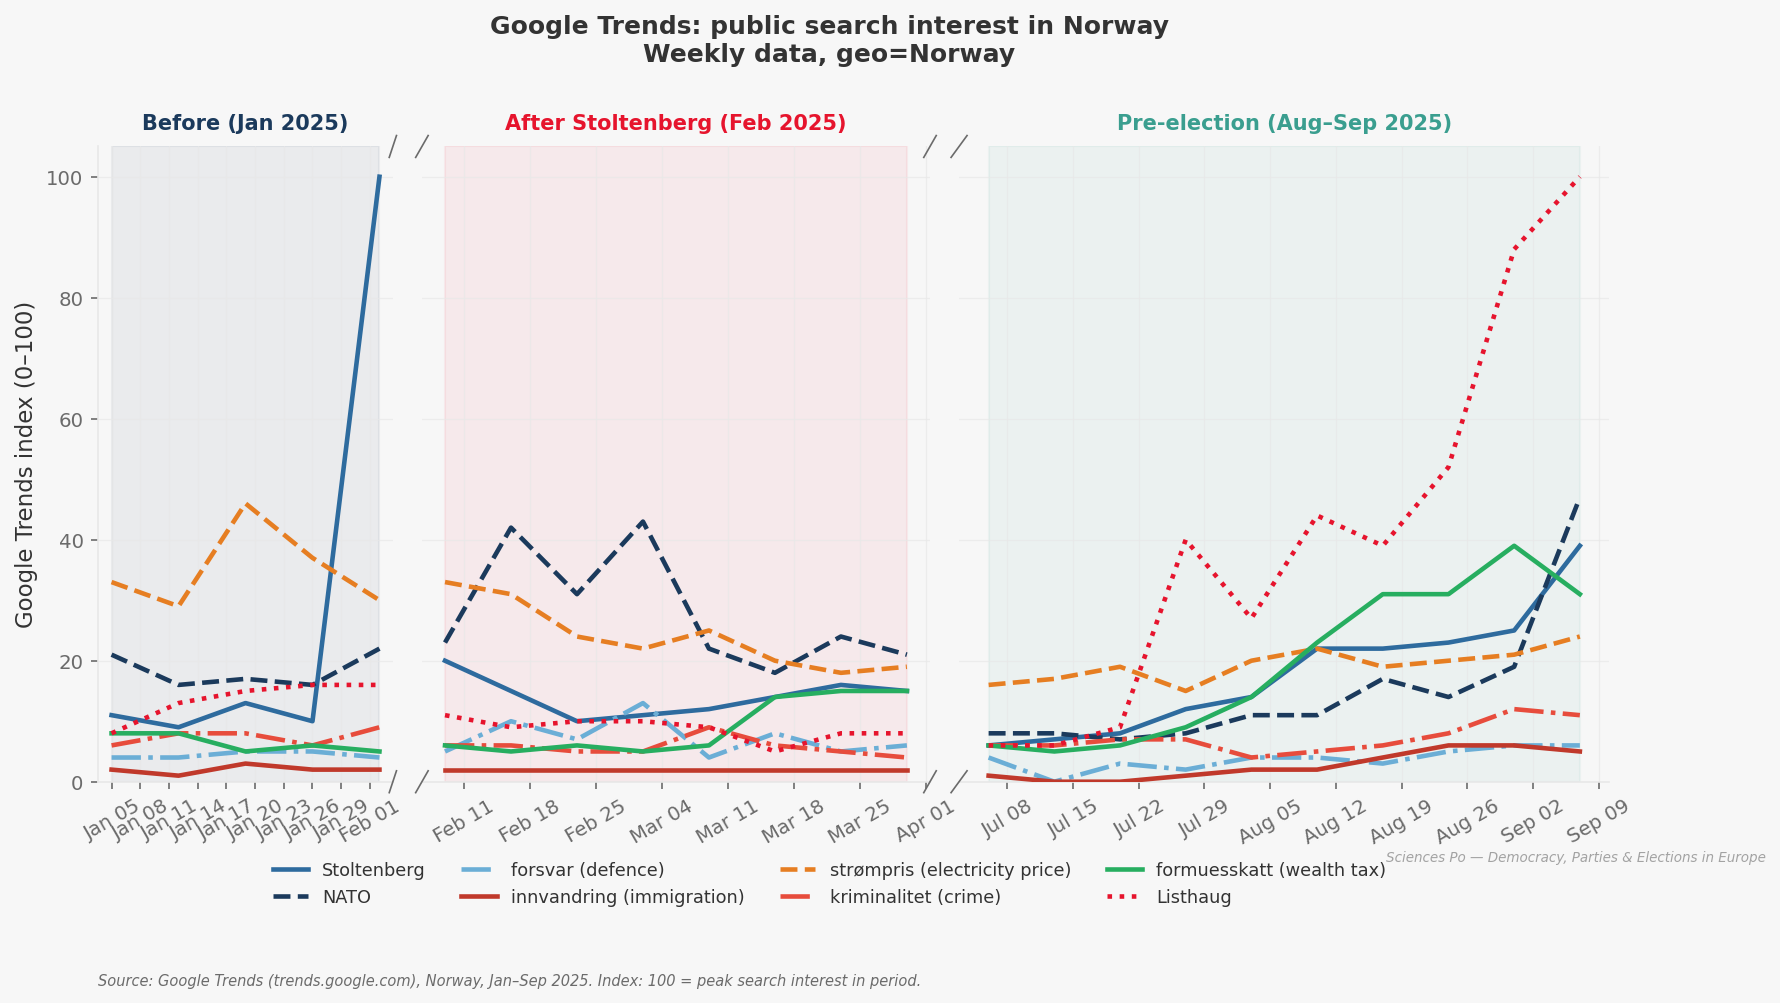

→ Saved fig_gtrends_broken.png/pdf


In [ ]:
if all_trends.empty:
    print("⚠ No Google Trends data loaded. Skipping plot.")
    print("  Place your downloaded CSVs in data/google_trends/ and re-run.")
else:
    OUTPUT_DIR = Path("output")
    OUTPUT_DIR.mkdir(exist_ok=True)

    visible = {k: v for k, v in SHOW_TERMS.items() if v and k in all_trends.columns}

    if not visible:
        available = [c for c in all_trends.columns if c in TERM_CONFIG]
        missing = [
            k for k, v in SHOW_TERMS.items() if v and k not in all_trends.columns
        ]
        print(f"⚠ No matching terms found in data.")
        print(f"  Available in CSV: {available}")
        print(f"  Requested but missing: {missing}")
        print(
            f"  Check that your SHOW_TERMS keys match the CSV column headers exactly."
        )
    else:
        # Assign periods to each week
        def get_period(d):
            if BEFORE_START <= d <= BEFORE_END:
                return "BEFORE"
            if AFTER_START <= d <= AFTER_END:
                return "AFTER"
            if ELECT_START <= d <= ELECT_END:
                return "ELECTION"
            return None

        all_trends["_period"] = all_trends.index.map(get_period)

        # Split by period
        period_dfs = {}
        for p in PERIOD_ORDER:
            sub = all_trends[all_trends["_period"] == p].copy()
            if not sub.empty:
                period_dfs[p] = sub

        active_p = [p for p in PERIOD_ORDER if p in period_dfs]

        if not active_p:
            print("⚠ No data falls within defined periods. Check your date ranges.")
        else:
            widths = []
            for p in active_p:
                span = (period_dfs[p].index.max() - period_dfs[p].index.min()).days + 1
                widths.append(max(span, 7))

            fig, axes = plt.subplots(
                1,
                len(active_p),
                sharey=True,
                figsize=(13, 5.5),
                gridspec_kw={"width_ratios": widths, "wspace": 0.06},
            )
            if len(active_p) == 1:
                axes = [axes]

            y_max = 0
            for idx, period in enumerate(active_p):
                ax = axes[idx]
                pdf = period_dfs[period]

                for term in visible:
                    if term not in pdf.columns:
                        continue
                    label, group, color, ls = TERM_CONFIG[term]
                    vals = pdf[term]
                    if WINDOW_GT > 1:
                        vals = vals.rolling(
                            WINDOW_GT, min_periods=1, center=True
                        ).mean()

                    ax.plot(
                        vals.index,
                        vals.values,
                        color=color,
                        linewidth=2.2,
                        linestyle=ls,
                        zorder=4,
                        label=label if idx == 0 else "_nolegend_",
                    )

                    y_max = max(y_max, vals.max())

                # Period tint
                ax.axvspan(
                    pdf.index.min(),
                    pdf.index.max(),
                    alpha=0.06,
                    color=PERIOD_COLORS[period],
                    zorder=0,
                )

                # Treatment line
                if pdf.index.min() <= TREATMENT_DATE <= pdf.index.max():
                    ax.axvline(
                        TREATMENT_DATE,
                        color=SCPO_RED,
                        linewidth=1.2,
                        linestyle="--",
                        alpha=0.7,
                        zorder=2,
                    )
                    ax.text(
                        TREATMENT_DATE,
                        y_max * 0.95,
                        "  Feb 4",
                        fontsize=7.5,
                        color=SCPO_RED,
                        style="italic",
                        va="top",
                    )

                ax.set_title(
                    PERIOD_LABELS[period].replace("\n", " "),
                    fontsize=10,
                    fontweight="bold",
                    color=PERIOD_COLORS[period],
                    pad=8,
                )

                ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
                ax.tick_params(axis="x", rotation=30)
                if len(pdf) > 6:
                    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
                else:
                    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))

                if idx > 0:
                    ax.spines["left"].set_visible(False)
                    ax.tick_params(left=False)
                if idx < len(active_p) - 1:
                    ax.spines["right"].set_visible(False)

            # Break marks
            def draw_break(ax_l, ax_r, d=0.015, angle=35):
                for ax, side in [(ax_l, "right"), (ax_r, "left")]:
                    x = 1.0 if side == "right" else 0.0
                    kw = dict(
                        transform=ax.transAxes,
                        color=SCPO_MIDGREY,
                        linewidth=0.8,
                        clip_on=False,
                        zorder=10,
                    )
                    dx = d * np.cos(np.radians(angle))
                    dy = d * np.sin(np.radians(angle)) * 2
                    ax.plot([x - dx, x + dx], [1 - dy, 1 + dy], **kw)
                    ax.plot([x - dx, x + dx], [0 - dy, 0 + dy], **kw)

            for i in range(len(active_p) - 1):
                draw_break(axes[i], axes[i + 1])

            axes[0].set_ylim(0, min(y_max * 1.2, 105))
            axes[0].set_ylabel("Google Trends index (0–100)")

            # Legend
            handles, labels = axes[0].get_legend_handles_labels()
            fig.legend(
                handles,
                labels,
                loc="lower center",
                bbox_to_anchor=(0.5, -0.06),
                fontsize=8.5,
                ncol=min(len(visible), 4),
                frameon=False,
            )

            hidden = [k for k, v in SHOW_TERMS.items() if not v and k in TERM_CONFIG]
            title_extra = f"\n(hidden: {', '.join(hidden)})" if hidden else ""
            fig.suptitle(
                "Google Trends: public search interest in Norway"
                f"\nWeekly data, geo=Norway{title_extra}",
                fontsize=12,
                fontweight="bold",
                color=SCPO_DARKGREY,
                y=1.04,
            )

            fig.tight_layout()
            fig.savefig(OUTPUT_DIR / "fig_gtrends_broken.png", bbox_inches="tight")
            fig.savefig(OUTPUT_DIR / "fig_gtrends_broken.pdf", bbox_inches="tight")
            plt.show()
            print("→ Saved fig_gtrends_broken.png/pdf")


## Summary: average search interest by period


In [25]:
if not all_trends.empty and active_p:
    print("=" * 65)
    print("GOOGLE TRENDS — Average search interest by period")
    print("=" * 65)

    summary_rows = []
    for term in TERM_CONFIG:
        if term not in all_trends.columns:
            continue
        label, group, _, _ = TERM_CONFIG[term]
        row = {"Term": label, "Issue group": group}
        for p in PERIOD_ORDER:
            if p in period_dfs:
                val = period_dfs[p][term].mean()
                row[p] = round(val, 1)
            else:
                row[p] = None
        if "BEFORE" in row and "AFTER" in row and row["BEFORE"] and row["AFTER"]:
            row["Δ BEFORE→AFTER"] = round(row["AFTER"] - row["BEFORE"], 1)
        summary_rows.append(row)

    df_summary = pd.DataFrame(summary_rows)
    if "Δ BEFORE→AFTER" in df_summary.columns:
        df_summary = df_summary.sort_values("Δ BEFORE→AFTER", ascending=False)
    print(df_summary.to_string(index=False))

    df_summary.to_csv(OUTPUT_DIR / "table_gtrends_summary.csv", index=False)
    print(f"\nSaved to {OUTPUT_DIR}/table_gtrends_summary.csv")


GOOGLE TRENDS — Average search interest by period
                         Term  Issue group  BEFORE  AFTER  ELECTION  Δ BEFORE→AFTER
                         NATO Labour-owned    18.4   28.0      15.0             9.6
            forsvar (defence) Labour-owned     4.4    7.2       3.7             2.8
    formuesskatt (wealth tax)    Contested     6.4    9.0      19.5             2.6
    innvandring (immigration)    FrP-owned     2.0    2.0       2.7             0.0
         kriminalitet (crime)    FrP-owned     7.4    5.8       7.2            -1.6
                     Listhaug   FrP-leader    13.6    8.8      41.1            -4.8
strømpris (electricity price)    FrP-owned    35.0   24.0      19.3           -11.0
                  Stoltenberg Labour-owned    28.6   14.1      17.8           -14.5

Saved to output/table_gtrends_summary.csv
